In [34]:
import numpy as np
import matplotlib.pyplot as plt
import rasterio
from pysheds.grid import Grid

In [35]:
dem_path = r"P:\snowmelt_stochastic_model\data\raw\SRTM\n32_e077_1arc_v3.tif"

with rasterio.open(dem_path) as src:
    print("CRS:", src.crs)
    print("Resolution:", src.res)
    print("Bounds:", src.bounds)
    print("Size:", src.width, src.height)

    dem = src.read(1)

CRS: EPSG:4326
Resolution: (0.0002777777777777778, 0.0002777777777777778)
Bounds: BoundingBox(left=76.99986111111112, bottom=31.999861111111112, right=78.0001388888889, top=33.00013888888889)
Size: 3601 3601


In [36]:
dem = dem.astype(float)

# SRTM nodata is usually -32768
dem[dem < 0] = np.nan

# Fill NaNs with median (ensures continuity)
median_val = np.nanmedian(dem)
dem[np.isnan(dem)] = median_val

print("DEM cleaned")

DEM cleaned


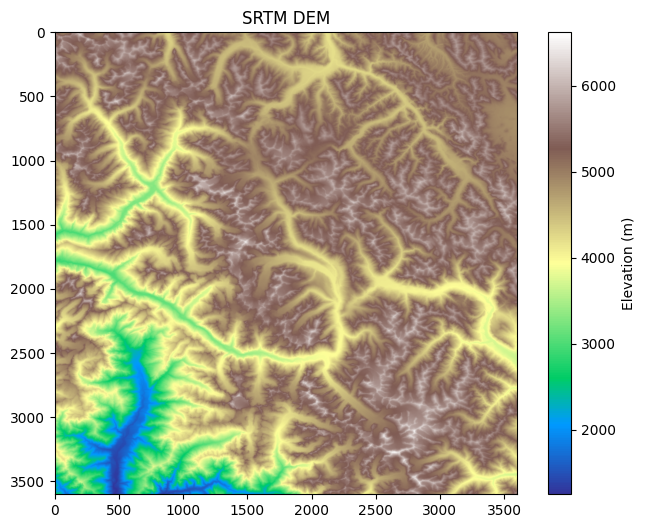

In [37]:
plt.figure(figsize=(8,6))
plt.imshow(dem, cmap='terrain')
plt.colorbar(label="Elevation (m)")
plt.title("SRTM DEM")
plt.show()

In [38]:
grid = Grid.from_raster(dem_path)
dem = grid.read_raster(dem_path)

# Clean again (important)
dem = dem.astype(float)
dem[dem < 0] = np.nan

median_val = np.nanmedian(dem)
dem[np.isnan(dem)] = median_val

In [39]:
dem_filled = grid.fill_pits(dem)
dem_filled = grid.fill_depressions(dem_filled)
dem_filled = grid.resolve_flats(dem_filled)

print("Hydrology preprocessing done")

Hydrology preprocessing done


In [40]:
flowdir = grid.flowdir(dem_filled)
acc = grid.accumulation(flowdir)

print("Min:", np.nanmin(acc), "Max:", np.nanmax(acc))

Min: 1.0 Max: 2828673.0


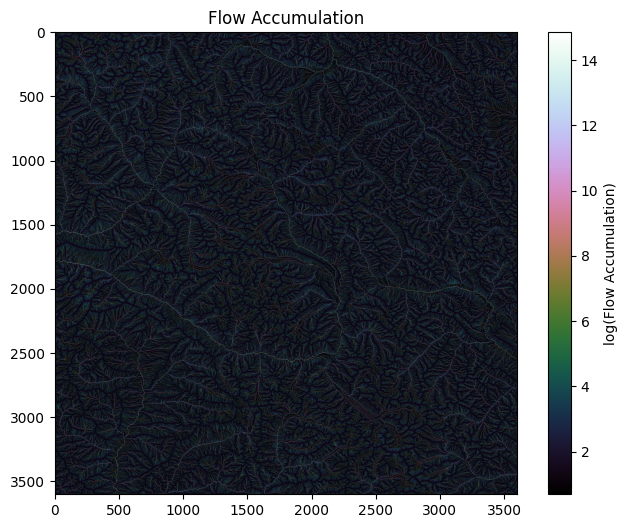

In [41]:
acc_log = np.log1p(acc)

plt.figure(figsize=(8,6))
plt.imshow(acc_log, cmap='cubehelix')
plt.colorbar(label="log(Flow Accumulation)")
plt.title("Flow Accumulation")
plt.show()

Threshold: 13588.0


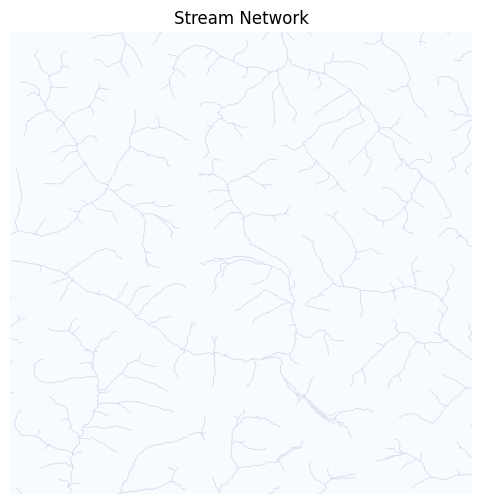

In [42]:
threshold = np.percentile(acc, 99.5)

print("Threshold:", threshold)

streams = acc > threshold

plt.figure(figsize=(8,6))
plt.imshow(streams, cmap='Blues')
plt.title("Stream Network")
plt.axis('off')
plt.show()

In [43]:
idx = np.unravel_index(np.argmax(acc), acc.shape)
row, col = idx

print("Outlet pixel:", row, col)

Outlet pixel: 1783 0


In [44]:
x_outlet, y_outlet = grid.affine * (col, row)

print("Outlet coords:", x_outlet, y_outlet)

Outlet coords: 76.99986111111112 32.50486111111111


In [45]:
x_snap, y_snap = grid.snap_to_mask(acc > threshold, (x_outlet, y_outlet))

print("Snapped outlet:", x_snap, y_snap)

Snapped outlet: 76.99986111111112 32.50486111111111


In [46]:
catch = grid.catchment(
    x=x_snap,
    y=y_snap,
    fdir=flowdir,
    xytype='coordinate'
)

grid.clip_to(catch)

print("Basin extracted")

Basin extracted


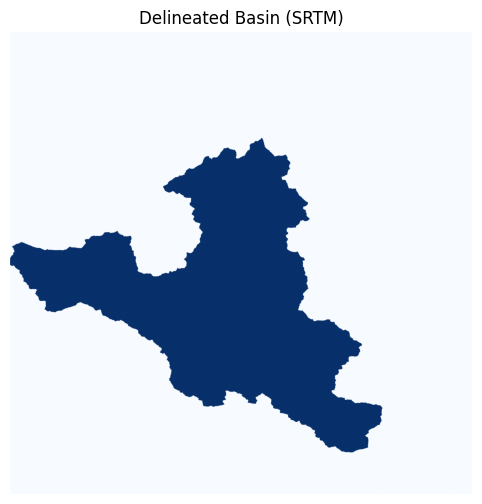

In [47]:
plt.figure(figsize=(8,6))
plt.imshow(catch, cmap='Blues')
plt.title("Delineated Basin (SRTM)")
plt.axis('off')
plt.show()

In [48]:
# Save basin mask as raster
with rasterio.open(
    r"P:\snowmelt_stochastic_model\data\processed\basin_mask.tif",
    "w",
    driver="GTiff",
    height=catch.shape[0],
    width=catch.shape[1],
    count=1,
    dtype=rasterio.uint8,
    crs=grid.crs,
    transform=grid.affine,
) as dst:
    dst.write(catch.astype(rasterio.uint8), 1)